<a href="https://colab.research.google.com/github/NOOBMASTER0016/Sign-language-repo/blob/main/SIGN_LANG_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Plan for Sign Language Detection Model Development

To develop a simple sign language detection model, we will follow these steps:

1.  **Data Loading**: Load the dataset, which typically consists of images or video frames of sign language gestures.
2.  **Data Preprocessing**: Prepare the data for model training. This may include resizing images, normalization, data augmentation, and splitting into training, validation, and test sets.
3.  **Model Building**: Design and implement a simple convolutional neural network (CNN) or a pre-trained model for image classification.
4.  **Model Training**: Train the model using the prepared dataset.
5.  **Model Evaluation**: Assess the model's performance using appropriate metrics (e.g., accuracy, precision, recall, F1-score).
6.  **Prediction/Inference**: Demonstrate how to use the trained model to make predictions on new data.

### 1. Data Loading

For sign language detection, datasets often consist of images or video frames. We will assume an image-based dataset where images are organized into subfolders representing different sign classes. We'll use `tf.keras.preprocessing.image_dataset_from_directory` to load the data efficiently. You will need to replace `'/path/to/your/dataset'` with the actual path to your sign language image dataset.

Attempting to load image from: /content/sample_data/1.avif
Successfully loaded and preprocessed image. Shape: (1, 128, 128, 3)


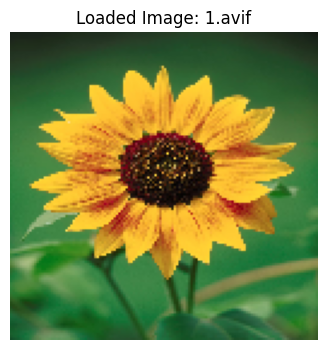

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os # Re-import os for os.path.basename

# Install imageio and imageio-ffmpeg for AVIF support
try:
    import imageio.v3 as iio
except ImportError:
    print("imageio not found. Installing...")
    !pip install imageio imageio-ffmpeg
    import imageio.v3 as iio

# Define parameters for image processing
IMG_HEIGHT = 128
IMG_WIDTH = 128

# The path to the specific AVIF image file provided by the user
IMAGE_FILE_PATH = '/content/sample_data/1.avif'

print(f"Attempting to load image from: {IMAGE_FILE_PATH}")

try:
    # Read the image using imageio
    img_np = iio.imread(IMAGE_FILE_PATH)
    # Convert NumPy array to TensorFlow tensor
    img = tf.convert_to_tensor(img_np, dtype=tf.float32)

    # Ensure 3 channels for RGB, if necessary (e.g., if image was grayscale)
    if img.shape[-1] == 4: # If RGBA, convert to RGB
        img = img[..., :3]
    elif img.shape[-1] == 1: # If grayscale, convert to RGB
        img = tf.image.grayscale_to_rgb(tf.expand_dims(img, axis=-1))

    # Resize the image
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])

    # Normalize the image to [0, 1] range
    img = img / 255.0

    # Expand dimensions to create a batch of 1 image (required for model prediction later)
    img_batch = tf.expand_dims(img, axis=0)

    print(f"Successfully loaded and preprocessed image. Shape: {img_batch.shape}")

    # Display the preprocessed image
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Loaded Image: {os.path.basename(IMAGE_FILE_PATH)}")
    plt.axis('off')
    plt.show()

except tf.errors.NotFoundError:
    print(f"Error: Image file not found at {IMAGE_FILE_PATH}. Please ensure the path is correct.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    print("Please check if the file is a valid AVIF and if imageio was installed correctly.")

# These variables are no longer directly relevant for single image loading
train_ds = None
val_ds = None
class_names = None
num_classes = None
AUTOTUNE = None